# 路由：条件分支
add_conditional_edges, 不使用pathmap路由多个分支。
观察图结构可以发现，node_a、node_b和node_c独立于图结构之外。

和上一节案例相比，router函数返回的是序列而非单个节点，渲染器无法推断节点间的映射关系。

In [1]:
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek

load_dotenv(override=True)

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)

{'topic': '猫咪', 'poem': '## 《午寐》\n\n瓷碗里沉底的晨光\n融化于棉质肚皮\n当窗台的暖色缓缓分岔\n胡须正拆卸正午的经纬\n\n爪痕在空气中生长成弧形\n翻动时坠落几粒灰色毛球\n忽然将右耳折成竖琴\n弦上滚过昨夜未拆封的雷声\n\n而尾巴垂落成水纹状\n在木纹里洄游\n所有未抵达的黄昏都盘成\n它喉间渐暗的嗡鸣', 'ci_poem': '想想猫咪柔软的小爪子、慵懒的呼噜声，或者它们那让人捉摸不透的眼神，一个词可能不足以概括。不过，如果一定要选一个我最喜欢的，那大概是：\n\n**“呼噜呼噜”**\n\n它不是一个标准词汇，但却是猫咪最治愈的声音。这个词可以是名词，也可以是动词：\n\n*   **作为名词**：它代表一种宁静的幸福。比如：“它在我腿上缩成一个毛团，发出轻柔的‘呼噜呼噜’。”\n*   **作为动词**：它描述了一种生命力的流淌。比如：“只要一摸它的下巴，它就开始呼噜呼噜起来，像一台小小的、毛茸茸的发动机。”\n\n---\n\n当然，如果你想看一首关于猫的词（就像宋词那样的），我这里倒是有一首小作：\n\n**《如梦令·霜猫》**\n\n昨夜梦回深巷，\n忽见银丸跳浪。\n月下捕流萤，\n踏碎一庭霜响。\n轻晃，轻晃，\n尾巴钓着月亮。\n\n---\n\n或者，如果你更喜欢朴实一点、像词语卡片一样的词：**“毛茸茸”**、**“傲娇”**、**“精灵”**、**“夜巡者”**、**“窗台上的哲学家”**……每一个词背后，都是猫咪的一个小宇宙。\n\n你心中有没有特别偏爱的一个词来形容猫咪呢？', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '当然！这里有一个关于猫咪的冷笑话，希望能让你会心一笑😼：\n\n**一只猫去饭店吃饭，服务员问：“您想点什么？”**  \n猫说：“喵喵喵喵喵。”  \n服务员（挠头）：“不好意思，我听不懂……”  \n猫叹了口气，从包里掏出一本《猫咪沟通指南》，翻到一页指给服务员看。  \n上面写着：**“一份三文鱼，谢谢，请务必新鲜。”**  \n服务员恍然大悟：“原来您会说人话啊？！”  \n猫白了他一眼：“当然会，但法律不让我们在工作场合以外说人话——怕你们人类有压力。”\n\n**（猫优雅地舔了舔爪子，补充道：）**“不过你们总爱给我

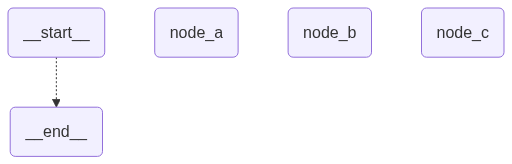

In [3]:
from typing import TypedDict, Literal, Sequence

from IPython.display import display
from langgraph.graph import StateGraph, START, END


# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    # 诗
    poem: str
    # 笑话
    joke: str
    # 词
    ci_poem: str
    content_type: str


# 2、定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(f"请写一个关于{state["topic"]}的诗").content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(f"请写一个关于{state["topic"]}的笑话").content
    return {
        "joke": joke
    }


def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke(f"请写一个关于{state["topic"]}的词").content
    return {
        "ci_poem": ci_poem
    }


# 定义路由
# 返回多个，需要用到Sequence
def route(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a", "node_c"]
    else:
        return ["node_b", "node_c"]


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_node(node_c)
# 不使用pathmap
builder.add_conditional_edges(START, route)
builder.add_edge("node_b", END)
builder.add_edge("node_a", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪", "content_type": "笑话"})
print(joke_res)

display(graph)